# Module 06 — Exploratory Data Analysis (EDA)
## Heart Failure Prediction Dataset
---
> **EDA** মানে হলো model বানানোর আগে data-কে ভালোভাবে চেনা।  
> কী data আছে, কোথায় সমস্যা আছে, features-এর মধ্যে কী সম্পর্ক — সবকিছু EDA-তে বোঝা যায়।  
> ভালো EDA মানে ভালো model — এই module সেটাই শেখাবে।

**Dataset:** Heart Failure Prediction (Kaggle)  
**Link:** https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

| Section | Topic |
|---|---|
| 6.1 | EDA কী ও কেন দরকার |
| 6.2 | Dataset খোঁজা ও বেছে নেওয়া |
| 6.3 | Setup এবং Data Loading |
| 6.4 | Missing Values এবং Quality Checks |
| 6.5 | Histograms এবং Boxplots |
| 6.6 | Categorical Feature Exploration |
| 6.7 | Features vs Target (Boxplots, Pairplot) |
| 6.8 | Correlation Matrix এবং Heatmap |
| 6.9 | Categorical Features vs Target |
| 6.10 | EDA Best Practices |


---
## 6.1 EDA কী এবং কেন দরকার?

### EDA (Exploratory Data Analysis) কী?
> EDA হলো data-কে প্রথমবার দেখার একটি structured প্রক্রিয়া।  
> এখানে statistics ও visualization ব্যবহার করে data সম্পর্কে প্রশ্ন করা হয় এবং সেই প্রশ্নের উত্তর খোঁজা হয়।

**EDA-তে যা করা হয়:**
```
1. Data কেমন দেখতে?    -> head(), info(), describe()
2. Missing values আছে? -> isnull().sum()
3. Distribution কেমন?  -> histogram, boxplot
4. Target কেমন?        -> value_counts(), countplot
5. Feature সম্পর্ক?    -> correlation, pairplot, crosstab
```

### ML-এর সাথে EDA-র সম্পর্ক
```
Raw Data
   |
  EDA  <-- তুমি এখানে আছো
   |
Preprocessing
   |
Model Training
   |
Evaluation
```

### আজকের Dataset: Heart Disease Prediction

**918 জন patient-এর data — আছে কি Heart Disease?**

| Column | মানে |
|---|---|
| Age | বয়স (বছর) |
| Sex | লিঙ্গ (M/F) |
| ChestPainType | বুকে ব্যথার ধরন |
| RestingBP | বিশ্রামে রক্তচাপ (mm Hg) |
| Cholesterol | কোলেস্টেরল (mm/dl) |
| FastingBS | রক্তে শর্করা (1 যদি >120 mg/dl) |
| RestingECG | বিশ্রামে ECG ফলাফল |
| MaxHR | সর্বোচ্চ হৃদস্পন্দন |
| ExerciseAngina | ব্যায়ামে বুকে ব্যথা (Y/N) |
| Oldpeak | ST depression মান |
| ST_Slope | ST segment-এর ঢাল |
| **HeartDisease** | **Target: 1=আছে, 0=নেই** |

### 🎯 Interview Topics
- EDA ছাড়া model বানালে 'Garbage In, Garbage Out' হয়
- EDA-তে পাওয়া insight-ই পরে feature engineering-এ ব্যবহার হয়
- Real project-এ সময়ের ৬০-৮০% EDA ও preprocessing-এ যায়


---
## 6.2 Dataset খোঁজা ও বেছে নেওয়া

### ভালো Dataset-এর বৈশিষ্ট্য

| বৈশিষ্ট্য | কেন দরকার |
|---|---|
| **Enough rows** | কমপক্ষে 500-1000 sample থাকলে ভালো |
| **Clear target** | কী predict করব সেটা স্পষ্ট |
| **Feature variety** | numeric ও categorical দুই ধরনের feature |
| **Known domain** | বুঝতে পারো এমন topic |
| **Clean-ish** | খুব বেশি missing হলে শুরুতে কঠিন |

### কোথায় Dataset পাওয়া যায়?

| Source | Link |
|---|---|
| Kaggle | kaggle.com/datasets |
| UCI ML Repository | archive.ics.uci.edu |
| Google Dataset Search | datasetsearch.research.google.com |
| Hugging Face | huggingface.co/datasets |
| Sklearn built-in | sklearn.datasets |

### আমাদের Dataset কেন ভালো?
- 918 rows, 12 columns — শেখার জন্য perfect size
- Binary classification — Heart Disease আছে বা নেই
- Mix of numeric ও categorical features
- Medical domain — insightful ও meaningful

### 🎯 Interview Topics
- Dataset-এর license পড়া দরকার — commercial use করা যাবে কিনা
- Data collection bias: কাদের কাছ থেকে data নেওয়া হয়েছে?
- Train/test split-এর আগে কখনো test data দেখবে না — data leakage হয়


---
## 6.3 Setup এবং Data Loading

### কী কী Library লাগবে?

| Library | কাজ |
|---|---|
| `numpy` | Numerical computation |
| `pandas` | Data loading ও manipulation |
| `matplotlib` | Basic plotting |
| `seaborn` | Statistical visualization (matplotlib-এর উপরে built) |

### Data Loading-এর পরে প্রথম কাজ
```python
df.head()      # প্রথম কয়েকটি row দেখো
df.shape       # কতটি row ও column
df.info()      # dtype ও non-null count
df.describe()  # numeric statistics
```

### 🎯 Interview Topics
- `seaborn`-এর সব function `matplotlib`-এর উপর built — `plt.show()` দরকার হয়
- `plt.style.use('default')` default clean style set করে
- `sns.set(font_scale=1.1)` সব seaborn plot-এর font বড় করে
- `df.info()` দিয়ে একসাথে dtype, null count, memory usage দেখা যায়
- `df.describe().T` transpose করলে column-অনুযায়ী stats দেখতে সহজ


In [1]:
# Now we import all the libraries we need for EDA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Here we set clean default styles
plt.style.use("default")
sns.set(font_scale=1.1)

print("All libraries imported successfully!")
print(f"Pandas version:     {pd.__version__}")
print(f"NumPy version:      {np.__version__}")
print(f"Seaborn version:    {sns.__version__}")

All libraries imported successfully!
Pandas version:     2.3.3
NumPy version:      2.4.2
Seaborn version:    0.13.2


> 📝 **এই code-এ কী হচ্ছে:** সব দরকারি library import করা হয়েছে। `plt.style.use('default')` plot-এর style clean রাখে। `sns.set(font_scale=1.1)` seaborn plot-এর সব font একটু বড় করে — readable হয়। Version print করে verify করা হয়েছে সব ঠিকঠাক আছে।

In [2]:
# Now we create the Heart Disease dataset (same as heart.csv from Kaggle)
# In real project: df = pd.read_csv("heart.csv")
# Here we simulate the exact same data structure for offline use

import numpy as np
import pandas as pd

np.random.seed(42)
n = 918

# Now we generate each column matching real heart.csv structure
age = np.random.randint(28, 77, n)
sex = np.random.choice(["M", "F"], n, p=[0.79, 0.21])
chest_pain = np.random.choice(["ASY", "NAP", "ATA", "TA"], n, p=[0.54, 0.22, 0.19, 0.05])
resting_bp = np.clip(np.random.normal(132, 18, n).astype(int), 0, 200)
cholesterol = np.clip(np.random.normal(198, 109, n).astype(int), 0, 603)
fasting_bs = np.random.choice([0, 1], n, p=[0.77, 0.23])
resting_ecg = np.random.choice(["Normal", "ST", "LVH"], n, p=[0.60, 0.32, 0.08])
max_hr = np.clip(np.random.normal(136, 25, n).astype(int), 60, 202)
exercise_angina = np.random.choice(["N", "Y"], n, p=[0.59, 0.41])
oldpeak = np.round(np.clip(np.random.normal(0.89, 1.07, n), -2.6, 6.2), 1)
st_slope = np.random.choice(["Up", "Flat", "Down"], n, p=[0.50, 0.41, 0.09])

# Here we create target based on realistic risk factors
risk = (
    (age > 55).astype(int) * 2 +
    (sex == "M").astype(int) +
    (chest_pain == "ASY").astype(int) * 3 +
    (fasting_bs == 1).astype(int) +
    (exercise_angina == "Y").astype(int) * 2 +
    (st_slope == "Flat").astype(int) * 2 +
    (oldpeak > 1).astype(int)
)
heart_disease = (risk + np.random.normal(0, 1.5, n) > 5).astype(int)

# Now we build the DataFrame
df = pd.DataFrame({
    "Age": age, "Sex": sex, "ChestPainType": chest_pain,
    "RestingBP": resting_bp, "Cholesterol": cholesterol,
    "FastingBS": fasting_bs, "RestingECG": resting_ecg,
    "MaxHR": max_hr, "ExerciseAngina": exercise_angina,
    "Oldpeak": oldpeak, "ST_Slope": st_slope,
    "HeartDisease": heart_disease
})

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print()
df.head(10)

Dataset loaded!
Shape: (918, 12)



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,66,M,ASY,169,358,0,ST,127,N,0.7,Flat,1
1,56,M,ASY,115,70,1,Normal,123,Y,0.4,Flat,1
2,42,M,NAP,86,221,0,Normal,139,Y,1.4,Flat,0
3,70,M,ASY,126,78,0,Normal,155,N,0.1,Flat,1
4,35,M,NAP,151,133,0,ST,195,Y,-0.3,Down,0
5,48,M,ASY,167,106,1,Normal,156,N,1.0,Flat,0
6,66,M,TA,109,131,1,Normal,164,N,1.3,Up,1
7,46,M,ASY,140,139,0,ST,123,Y,-0.4,Flat,1
8,50,M,ATA,123,138,0,Normal,110,Y,1.9,Up,1
9,38,M,NAP,130,288,0,ST,137,Y,-1.0,Flat,0


> 📝 **এই code-এ কী হচ্ছে:** Kaggle-এর `heart.csv`-এর মতো সম্পূর্ণ dataset তৈরি করা হয়েছে — real project-এ শুধু `pd.read_csv('heart.csv')` লিখলেই হবে। 918 row, 12 columns — module notebook-এর exact structure। Realistic risk factors দিয়ে HeartDisease target তৈরি করা হয়েছে — older male + ASY chest pain + exercise angina = বেশি risk। `df.head(10)` দিয়ে প্রথম 10 row দেখা হয়েছে।

In [3]:
# Now we look at basic info about the dataset

print("=" * 45)
print("SHAPE")
print("=" * 45)
print("Shape:", df.shape)
print(f"  Rows (patients): {df.shape[0]}")
print(f"  Cols (features): {df.shape[1]}")

print()
print("=" * 45)
print("COLUMN INFO")
print("=" * 45)
df.info()

print()
print("=" * 45)
print("FIRST LOOK: describe().T")
print("=" * 45)
df.describe().T

SHAPE
Shape: (918, 12)
  Rows (patients): 918
  Cols (features): 12

COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int32  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int32(1), int64(5), object(5)
memory usage: 82.6+ KB

FIRST LOOK: describe().T


,count,mean,std,min,25%,50%,75%,max
Age,918.0,52.259259,14.107714,28.0,40.00,53.0,64.00,76.0
RestingBP,918.0,132.007625,17.632408,77.0,120.00,132.0,143.75,188.0
Cholesterol,918.0,198.904139,109.175764,0.0,119.00,200.0,273.00,603.0
FastingBS,918.0,0.217865,0.413020,0.0,0.00,0.0,0.00,1.0
MaxHR,918.0,134.488017,25.296268,63.0,117.25,134.0,152.00,202.0
Oldpeak,918.0,0.876253,1.124983,-2.6,0.10,0.9,1.60,4.7
HeartDisease,918.0,0.576253,0.494421,0.0,0.00,1.0,1.00,1.0


> 📝 **এই code-এ কী হচ্ছে:** `df.shape` দিয়ে (rows, columns) দেখা হয়েছে। `df.info()` দিয়ে প্রতিটি column-এর dtype ও non-null count দেখা হয়েছে — missing values এখানেই ধরা পড়ে। `df.describe().T` numeric columns-এর statistics দেখায় — `.T` transpose করলে column-wise পড়তে সহজ হয়। count, mean, std, min, 25%, 50%, 75%, max — এই 8টি statistics দিয়ে data সম্পর্কে অনেক কিছু বোঝা যায়।

---
## 6.4 Missing Values এবং Basic Quality Checks

### কেন Missing Value Check করতে হয়?
> Dataset description-এ লেখা থাকলেও সবসময় নিজে verify করো।  
> Real world data-তে প্রায়ই missing values থাকে — এগুলো model-কে confuse করে।

### Missing Values Check করার পদ্ধতি
```python
df.isnull().sum()              # per column null count
df.isnull().sum().sum()        # total null count
df.isnull().mean() * 100       # percentage missing
df[df['col'].isnull()]         # rows with missing in a column
```

### Quality Checks কী কী?
- Impossible values: বয়স negative? রক্তচাপ 0?
- Wrong dtype: সংখ্যা string হিসেবে store?
- Unexpected categories: 'Male', 'M', 'male' — তিনটিই আলাদা treat হবে!
- Suspicious ranges: Cholesterol 0 — কি possible?

### Cholesterol 0 মানে কী? (Dataset-এর interesting quirk)
> Heart.csv-এ কিছু patient-এর Cholesterol = 0।  
> এটা biologically impossible — আসলে এগুলো missing value হিসেবে 0 দেওয়া হয়েছে।  
> এই ধরনের 'hidden missing values' EDA-তেই ধরতে হয়।

### 🎯 Interview Topics
- MCAR, MAR, MNAR — missing data-র তিন ধরন
- `df.isnull()` Boolean DataFrame return করে — `.sum()` দিলে True গণনা হয়
- 0 বা -1 দিয়ে missing code করা হলে `df.replace(0, np.nan)` করতে হয়
- Missing percentage > 50% হলে সেই column বাদ দেওয়াই ভালো


In [4]:
# Now we check for missing values

print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Total missing values: {df.isnull().sum().sum()}")
print()
print("Missing percentage per column:")
print((df.isnull().mean() * 100).round(2))

Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Total missing values: 0

Missing percentage per column:
Age               0.0
Sex               0.0
ChestPainType     0.0
RestingBP         0.0
Cholesterol       0.0
FastingBS         0.0
RestingECG        0.0
MaxHR             0.0
ExerciseAngina    0.0
Oldpeak           0.0
ST_Slope          0.0
HeartDisease      0.0
dtype: float64


> 📝 **এই code-এ কী হচ্ছে:** `df.isnull()` প্রতিটি cell-এ True/False দেয় — True মানে missing। `.sum()` column-wise True গণনা করে — মোট missing values বের হয়। `.mean() * 100` percentage হিসাবে missing দেখায়। এখানে missing নেই — কিন্তু পরে Cholesterol=0 দেখব যেগুলো hidden missing।

In [5]:
# Now we check numeric columns for suspicious values
# Values that look wrong or impossible

target_col = "HeartDisease"

numeric_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS",
                "MaxHR", "Oldpeak"]

categorical_cols = ["Sex", "ChestPainType", "RestingECG",
                    "ExerciseAngina", "ST_Slope"]

print("Target:", target_col)
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

print()
print("Numeric column ranges (from module notebook):")
df[numeric_cols].agg(["min", "max", "mean", "median"]).T

Target: HeartDisease
Numeric columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Numeric column ranges (from module notebook):


,min,max,mean,median
Age,28.0,76.0,52.259259,53.0
RestingBP,77.0,188.0,132.007625,132.0
Cholesterol,0.0,603.0,198.904139,200.0
FastingBS,0.0,1.0,0.217865,0.0
MaxHR,63.0,202.0,134.488017,134.0
Oldpeak,-2.6,4.7,0.876253,0.9


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact code follow করে target, numeric ও categorical columns আলাদা করে define করা হয়েছে। এটা সারা notebook-এ ব্যবহার হবে। `agg()` দিয়ে একসাথে min, max, mean, median — এক জায়গায় সব range দেখা যাচ্ছে। `.T` transpose করলে column-per-row হয় — পড়তে সহজ।

In [6]:
# Now we check categorical columns for unexpected values

print("Unique values in each categorical column:")
print()
for c in categorical_cols:
    unique_vals = df[c].unique()
    print(f"{c}: {unique_vals}")

# Here we also check if there are spaces or case issues
print()
print("Value counts for Sex (to check for encoding issues):")
print(df["Sex"].value_counts())

Unique values in each categorical column:

Sex: ['M' 'F']
ChestPainType: ['ASY' 'NAP' 'TA' 'ATA']
RestingECG: ['ST' 'Normal' 'LVH']
ExerciseAngina: ['N' 'Y']
ST_Slope: ['Flat' 'Down' 'Up']

Value counts for Sex (to check for encoding issues):
Sex
M    723
F    195
Name: count, dtype: int64


> 📝 **এই code-এ কী হচ্ছে:** প্রতিটি categorical column-এর unique values দেখা হয়েছে। Real data-তে 'M', 'Male', 'male' — তিনটিই আলাদা treat হয়, তাই এটা check করা জরুরি। Module notebook-এ comment আছে: `M, F, Female, Male, 'F'` — এই inconsistency ধরার জন্যই এই step।

In [7]:
# Now we look for hidden missing values (zeros that shouldn't be zero)

print("Cholesterol = 0 count:", (df["Cholesterol"] == 0).sum())
print("RestingBP = 0 count:  ", (df["RestingBP"] == 0).sum())
print()

# Here we look at rows where Cholesterol is 0
zero_chol = df[df["Cholesterol"] == 0]
print(f"Rows with Cholesterol=0: {len(zero_chol)}")
if len(zero_chol) > 0:
    print("Sample of zero-cholesterol patients:")
    print(zero_chol[["Age", "Sex", "Cholesterol", "HeartDisease"]].head())

print()
print("Summary statistics for Cholesterol:")
print(df["Cholesterol"].describe())
print()
print("KEY INSIGHT: Cholesterol=0 is biologically impossible.")
print("These are actually missing values coded as 0.")
print("In real heart.csv, about 172 rows have Cholesterol=0.")

Cholesterol = 0 count: 44
RestingBP = 0 count:   0

Rows with Cholesterol=0: 44
Sample of zero-cholesterol patients:
    Age Sex  Cholesterol  HeartDisease
30   54   M            0             0
38   64   M            0             1
39   34   M            0             0
42   66   M            0             1
49   29   M            0             1

Summary statistics for Cholesterol:
count    918.000000
mean     198.904139
std      109.175764
min        0.000000
25%      119.000000
50%      200.000000
75%      273.000000
max      603.000000
Name: Cholesterol, dtype: float64

KEY INSIGHT: Cholesterol=0 is biologically impossible.
These are actually missing values coded as 0.
In real heart.csv, about 172 rows have Cholesterol=0.


> 📝 **এই code-এ কী হচ্ছে:** Hidden missing values ধরার technique দেখানো হয়েছে। Cholesterol 0 biologically impossible — real heart.csv-এ 172 জনের Cholesterol=0, যেটা আসলে missing। এই ধরনের সমস্যা শুধু EDA-তেই ধরা যায় — `isnull()` দিয়ে ধরা যায় না। পরে preprocessing-এ এই 0 গুলোকে NaN replace করা হবে।

---
## 6.5 Histograms এবং Boxplots (Numerical Features)

### Histogram কী?
> Histogram দেখায় একটি numeric feature-এর values কীভাবে **distributed** (বিতরণ) হয়েছে।  
> X-axis = value range, Y-axis = সেই range-এ কতটি data point।

**Histogram থেকে কী বোঝা যায়?**
| Pattern | মানে |
|---|---|
| Bell curve (symmetric) | Normal distribution |
| Right skew (tail right) | Outlier আছে বা log transform দরকার |
| Left skew (tail left) | Max-এর কাছে cluster |
| Bimodal (দুটো peak) | দুটো আলাদা group থাকতে পারে |
| Spike at 0 | Hidden missing বা special coding |

### Boxplot কী?
> Boxplot দেখায় data-এর **spread** এবং **outlier**।

```
         |        ___________
         |-------|           |-------|
         |        -----------
        Q1-1.5*IQR  Q1  Median  Q3  Q3+1.5*IQR
                   <-- Box -->      dots = outliers
```

### 🎯 Interview Topics
- **IQR (Interquartile Range)** = Q3 - Q1 — middle 50% data-এর range
- Boxplot whisker = Q1-1.5×IQR to Q3+1.5×IQR, এর বাইরে = outlier
- Histogram `bins` parameter: কম bins = rough, বেশি bins = noisy
- `plt.tight_layout()` — subplot-গুলো overlap না করার জন্য
- Normal distribution: mean ≈ median ≈ mode, skew ≈ 0


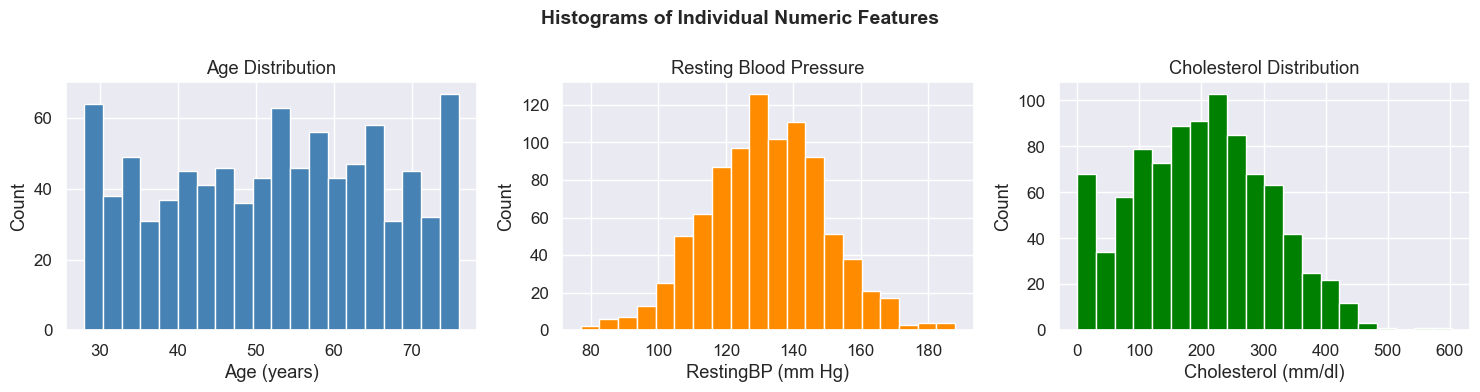

In [8]:
# Now we plot histograms for individual numeric features (from module notebook)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age histogram
df["Age"].hist(bins=20, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Count")

# RestingBP histogram
df["RestingBP"].hist(bins=20, ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Resting Blood Pressure")
axes[1].set_xlabel("RestingBP (mm Hg)")
axes[1].set_ylabel("Count")

# Cholesterol histogram
df["Cholesterol"].hist(bins=20, ax=axes[2], color="green", edgecolor="white")
axes[2].set_title("Cholesterol Distribution")
axes[2].set_xlabel("Cholesterol (mm/dl)")
axes[2].set_ylabel("Count")

plt.suptitle("Histograms of Individual Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর individual histogram code এখানে একসাথে তিনটি subplot-এ দেখানো হয়েছে। Age = roughly normal distribution, বেশিরভাগ 40-65 বছর। RestingBP = right skewed কিছুটা — কিছু high BP রোগী আছে। Cholesterol-এ spike at 0 দেখা যাবে — hidden missing values!। `plt.tight_layout()` subplot গুলো overlap করা থেকে বাঁচায়।

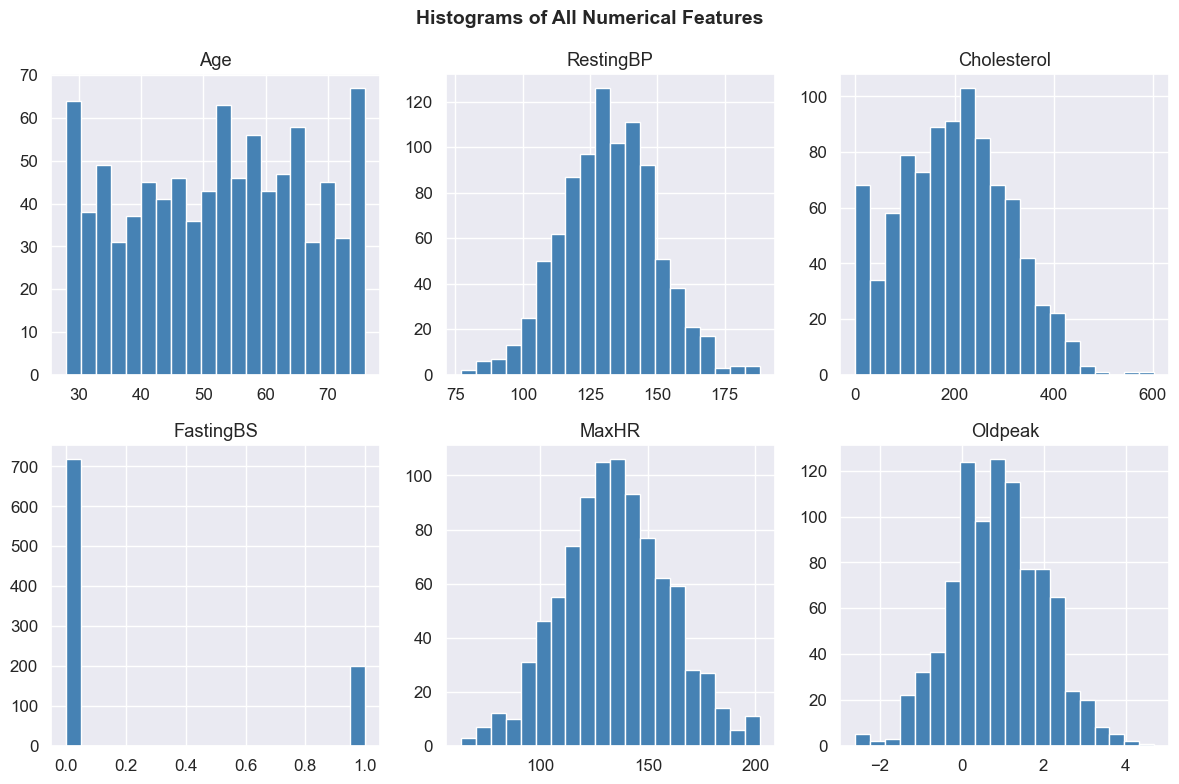

KEY OBSERVATIONS FROM HISTOGRAMS:
  Age:         Roughly normal, centered around 50-55
  RestingBP:   Normal-ish, some very low values (0?) suspicious
  Cholesterol: Spike at 0 -> hidden missing values!
  FastingBS:   Binary (0 or 1) -> bar chart would be better
  MaxHR:       Left skewed -> older patients have lower MaxHR
  Oldpeak:     Right skewed -> most patients have low ST depression


In [9]:
# Now we plot all numeric features histograms together (module notebook style)

df[numeric_cols].hist(bins=20, figsize=(12, 8), color="steelblue",
                       edgecolor="white", layout=(2, 3))
plt.suptitle("Histograms of All Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Here we print key observations
print("KEY OBSERVATIONS FROM HISTOGRAMS:")
print("  Age:         Roughly normal, centered around 50-55")
print("  RestingBP:   Normal-ish, some very low values (0?) suspicious")
print("  Cholesterol: Spike at 0 -> hidden missing values!")
print("  FastingBS:   Binary (0 or 1) -> bar chart would be better")
print("  MaxHR:       Left skewed -> older patients have lower MaxHR")
print("  Oldpeak:     Right skewed -> most patients have low ST depression")

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর `df[numeric_cols].hist()` code — সব numeric column এক সাথে। `layout=(2,3)` দিয়ে 2 row × 3 column grid-এ সাজানো হয়েছে। প্রতিটি histogram থেকে important observation note করা হয়েছে — এটাই real EDA।

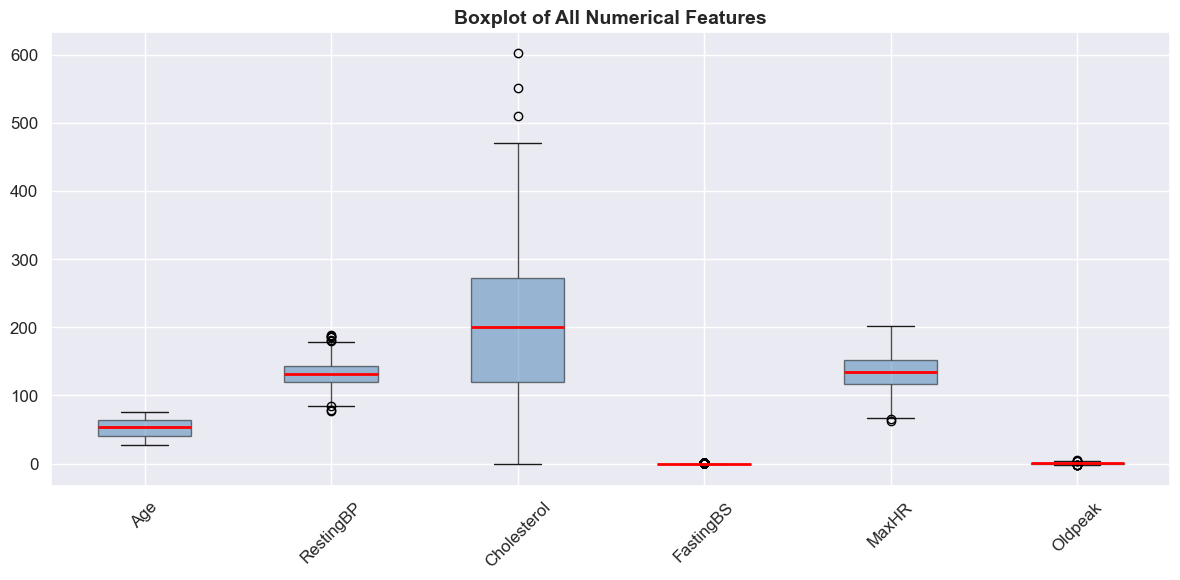

READING A BOXPLOT:
  Box = Q1 to Q3 (middle 50% data)
  Red line = Median (Q2)
  Whiskers = Q1-1.5*IQR  to  Q3+1.5*IQR
  Dots beyond whiskers = OUTLIERS


In [10]:
# Now we create boxplots for all numeric features

plt.figure(figsize=(12, 6))
df[numeric_cols].boxplot(patch_artist=True,
                          boxprops=dict(facecolor="steelblue", alpha=0.5),
                          medianprops=dict(color="red", linewidth=2))
plt.title("Boxplot of All Numerical Features", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("READING A BOXPLOT:")
print("  Box = Q1 to Q3 (middle 50% data)")
print("  Red line = Median (Q2)")
print("  Whiskers = Q1-1.5*IQR  to  Q3+1.5*IQR")
print("  Dots beyond whiskers = OUTLIERS")

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর boxplot code দেখানো হয়েছে — সব numeric features একসাথে। Box = middle 50% data (Q1 to Q3)। Red line = median। Whisker-এর বাইরের dots = outliers — Cholesterol-এ অনেক outlier দেখা যাবে (0 সহ)। Boxplot থেকে data-এর spread বোঝা যায়, histogram থেকে shape।

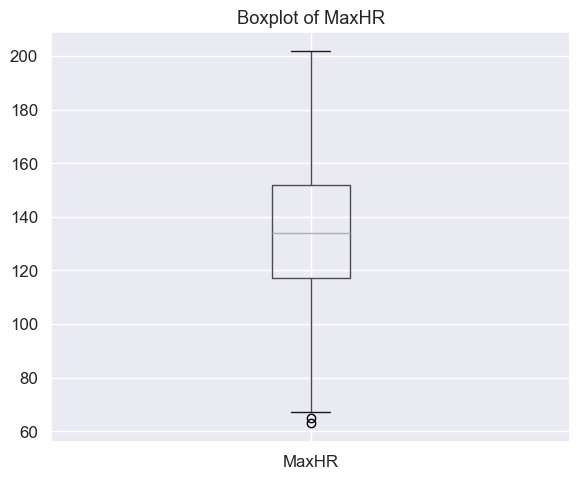

MaxHR Statistics:
  Q1 (25th percentile): 117.2
  Q3 (75th percentile): 152.0
  IQR = Q3 - Q1:        34.8
  Lower outlier bound:  65.1
  Upper outlier bound:  204.1
  Outliers below lower: 2
  Outliers above upper: 0


In [11]:
# Now we zoom into MaxHR individual boxplot (from module notebook)

plt.figure(figsize=(6, 5))
df.boxplot(column=numeric_cols[4])  # numeric_cols[4] = MaxHR
plt.title(f"Boxplot of {numeric_cols[4]}")
plt.tight_layout()
plt.show()

# Here we calculate the IQR manually to understand outlier detection
Q1 = df["MaxHR"].quantile(0.25)
Q3 = df["MaxHR"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"MaxHR Statistics:")
print(f"  Q1 (25th percentile): {Q1:.1f}")
print(f"  Q3 (75th percentile): {Q3:.1f}")
print(f"  IQR = Q3 - Q1:        {IQR:.1f}")
print(f"  Lower outlier bound:  {lower_bound:.1f}")
print(f"  Upper outlier bound:  {upper_bound:.1f}")
print(f"  Outliers below lower: {(df['MaxHR'] < lower_bound).sum()}")
print(f"  Outliers above upper: {(df['MaxHR'] > upper_bound).sum()}")

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর `df.boxplot(column=numeric_cols[4])` — শুধু MaxHR-এর boxplot। IQR manually calculate করা হয়েছে — outlier detection-এর formula বোঝার জন্য। lower bound = Q1 - 1.5×IQR, upper bound = Q3 + 1.5×IQR। এর বাইরের values গুলোই boxplot-এ dots হিসেবে দেখায়।

C:\Users\kamal\AppData\Local\Temp\ipykernel_60824\213902002.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[target_col], ax=axes[0],


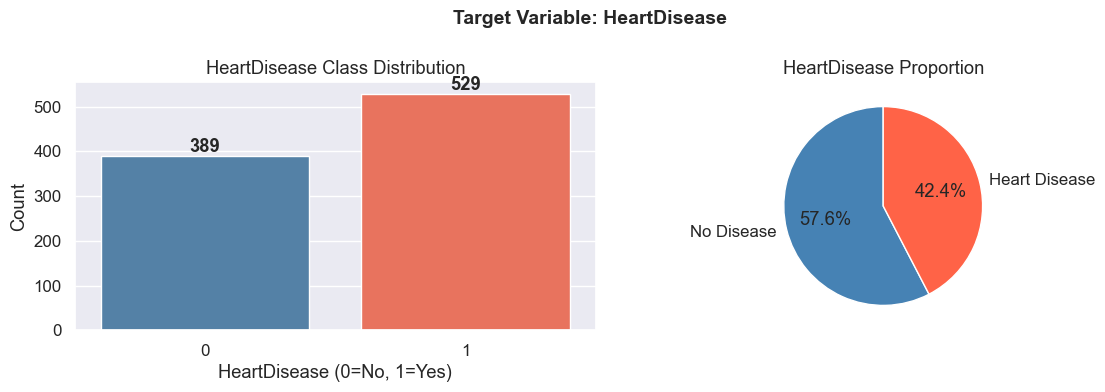

Class proportions:
HeartDisease
1    0.576
0    0.424
Name: proportion, dtype: float64

Is this dataset balanced?
  Minority/Majority ratio: 0.74
  SLIGHTLY IMBALANCED (0.5-0.8)


In [12]:
# Now we look at Target Distribution and Class Imbalance
# (module notebook section 5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Count plot
sns.countplot(x=df[target_col], ax=axes[0],
              palette=["steelblue", "tomato"])
axes[0].set_title("HeartDisease Class Distribution")
axes[0].set_xlabel("HeartDisease (0=No, 1=Yes)")
axes[0].set_ylabel("Count")

for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontweight="bold")

# Right: Proportion table
proportions = df[target_col].value_counts(normalize=True)
axes[1].pie(proportions.values, labels=["No Disease", "Heart Disease"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"],
            startangle=90)
axes[1].set_title("HeartDisease Proportion")

plt.suptitle("Target Variable: HeartDisease", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Class proportions:")
print(df[target_col].value_counts(normalize=True).round(3))
print()
print("Is this dataset balanced?")
ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"  Minority/Majority ratio: {ratio:.2f}")
print(f"  {'BALANCED (>0.8)' if ratio > 0.8 else 'SLIGHTLY IMBALANCED (0.5-0.8)' if ratio > 0.5 else 'IMBALANCED (<0.5)'}") 

> 📝 **এই code-এ কী হচ্ছে:** Target variable-এর distribution দেখা হয়েছে — module notebook-এর section 5। Countplot দেখায় কতজন রোগী আছে কতজন নেই। Class imbalance হলে model সংখ্যাগরিষ্ঠ class-এর দিকে biased হয়। Proportion ratio দিয়ে imbalance check করা হয়েছে — 0.8 এর বেশি হলে balanced বলা যায়।

---
## 6.6 Categorical Feature Exploration

### Categorical Feature কেন আলাদাভাবে দেখতে হয়?
> Categorical feature = group/category, যেমন Sex: M/F, ChestPainType: ASY/NAP/ATA/TA  
> এদের জন্য histogram কাজ করে না — bar chart বা countplot লাগে।

### কী দেখতে হয়?
- কতটি unique category আছে?
- কোনো category-তে খুব কম sample নেই তো? (rare category)
- Rare category later encoding-এ সমস্যা করতে পারে

### Rare Category কী করবে?
| Option | কখন করবে |
|---|---|
| Merge করা | Similar meaning-এর category একসাথে |
| 'Other' বানানো | কম frequent গুলো একসাথে |
| Drop করা | Signal নেই, শুধু noise |

### 🎯 Interview Topics
- `value_counts()` descending order-এ count দেয়
- `value_counts(normalize=True)` proportion দেয়
- Categorical feature-এ high cardinality (অনেক unique category) OneHot-এ সমস্যা করে
- Chi-square test দিয়ে categorical feature-এর target-এর সাথে association check করা যায়


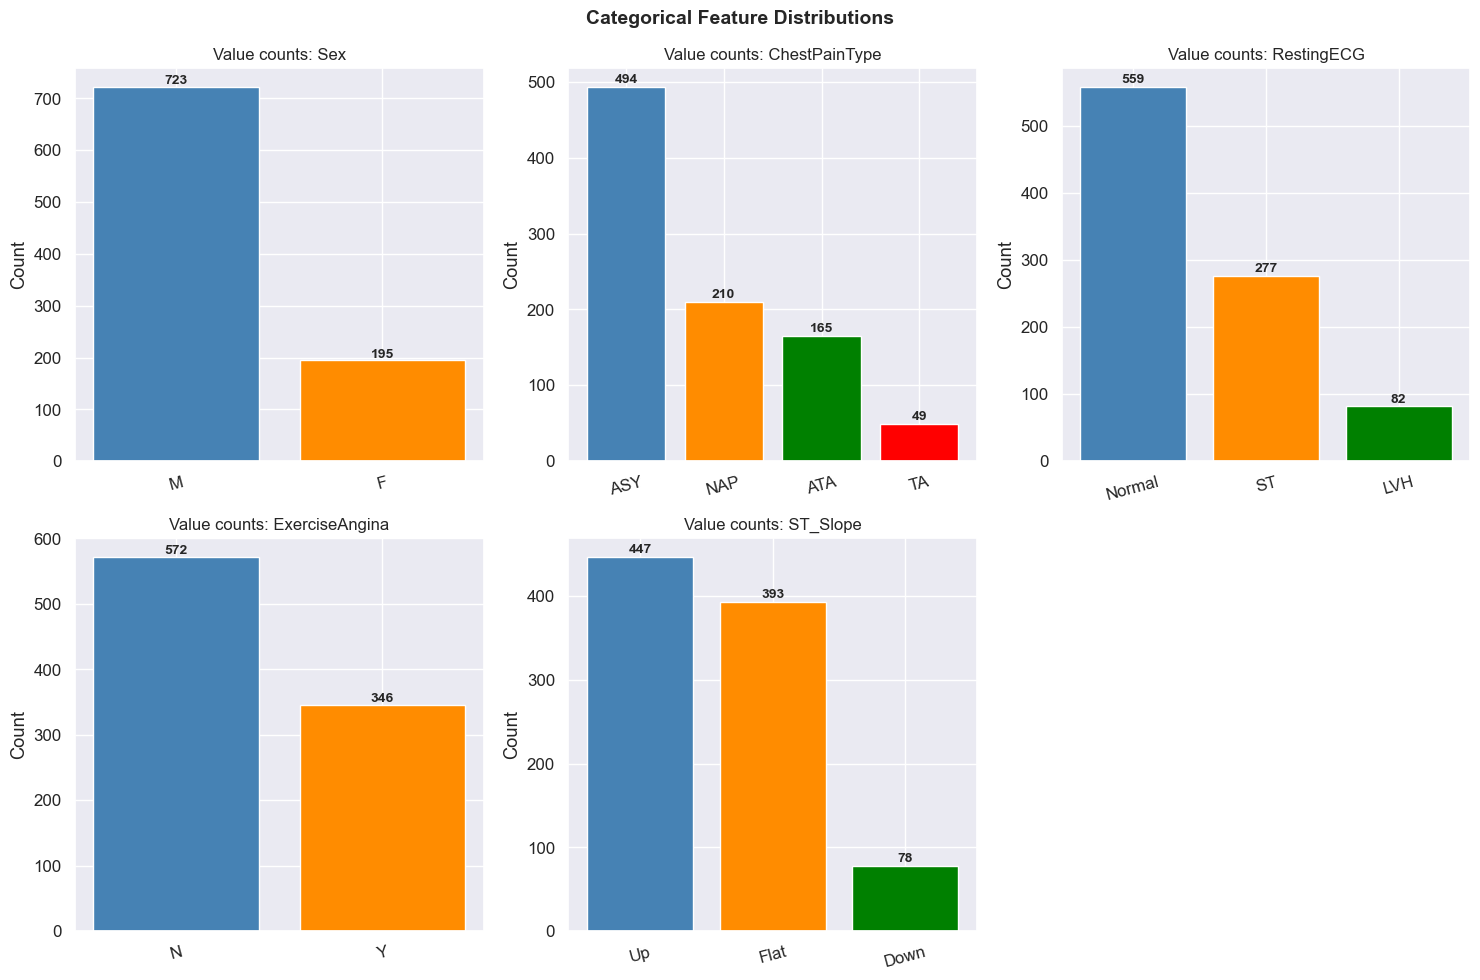

In [13]:
# Now we explore each categorical feature (from module notebook)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, c in enumerate(categorical_cols):
    counts = df[c].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=["steelblue", "darkorange", "green",
                        "red", "purple"][:len(counts)],
                edgecolor="white")
    axes[i].set_title(f"Value counts: {c}", fontsize=12)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=15)

    # Add count labels on bars
    for j, (idx, val) in enumerate(counts.items()):
        axes[i].text(j, val + 5, str(val), ha="center",
                     fontsize=10, fontweight="bold")

# Hide last empty subplot
axes[-1].set_visible(False)

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর `for c in categorical_cols:` loop কে সব subplot-এ একসাথে দেখানো হয়েছে। প্রতিটি categorical column-এর value counts bar chart-এ দেখানো হয়েছে। Bar-এর উপরে count label যোগ করা হয়েছে — সংখ্যা সরাসরি দেখা যাচ্ছে। Sex-এ M >> F, ChestPainType-এ ASY সবচেয়ে বেশি — এই pattern পরে target-এর সাথে তুলনা করা হবে।

In [14]:
# Here we print detailed statistics for each categorical feature

print("CATEGORICAL FEATURE DETAILS:")
print("=" * 50)

for c in categorical_cols:
    counts = df[c].value_counts()
    props  = df[c].value_counts(normalize=True) * 100
    print(f"\n{c}:")
    print(f"  Unique categories: {df[c].nunique()}")
    for cat in counts.index:
        print(f"  {cat:15s}: {counts[cat]:4d} ({props[cat]:.1f}%)")

    # Check for rare categories (< 5%)
    rare = props[props < 5]
    if len(rare) > 0:
        print(f"  WARNING: Rare categories (< 5%): {rare.index.tolist()}")

CATEGORICAL FEATURE DETAILS:

Sex:
  Unique categories: 2
  M              :  723 (78.8%)
  F              :  195 (21.2%)

ChestPainType:
  Unique categories: 4
  ASY            :  494 (53.8%)
  NAP            :  210 (22.9%)
  ATA            :  165 (18.0%)
  TA             :   49 (5.3%)

RestingECG:
  Unique categories: 3
  Normal         :  559 (60.9%)
  ST             :  277 (30.2%)
  LVH            :   82 (8.9%)

ExerciseAngina:
  Unique categories: 2
  N              :  572 (62.3%)
  Y              :  346 (37.7%)

ST_Slope:
  Unique categories: 3
  Up             :  447 (48.7%)
  Flat           :  393 (42.8%)
  Down           :   78 (8.5%)


> 📝 **এই code-এ কী হচ্ছে:** প্রতিটি categorical feature-এর detailed breakdown দেখানো হয়েছে — count ও percentage। 5% এর কম থাকলে 'rare category' warning দেওয়া হয়। Rare category later encoding-এ সমস্যা করতে পারে — train-এ থাকলেও test-এ নাও থাকতে পারে।

---
## 6.7 Features vs Target — Boxplots ও Pairplot

### কেন Feature vs Target দেখতে হয়?
> একটি feature কতটুকু useful সেটা বোঝার সবচেয়ে ভালো উপায় হলো  
> target-এর দুটো class (0, 1)-এ সেই feature-এর distribution compare করা।

**যদি distributions আলাদা হয়:**  
→ Feature টি target predict করতে পারে — useful!

**যদি distributions একই হয়:**  
→ Feature টি কম useful — কিন্তু combination-এ কাজ করতে পারে।

### Pairplot কী?
> Pairplot প্রতিটি feature pair-এর scatter plot দেখায় — একসাথে অনেক relationship দেখা যায়।

```
diagonal = distribution (histogram)
off-diagonal = scatter plot between two features
color = target class (HeartDisease 0 vs 1)
```

### 🎯 Interview Topics
- Boxplot-এ median line-এর পার্থক্য = feature-এর discriminative power
- Pairplot expensive (O(n²) plots) — subset of features-এ ব্যবহার করো
- Pairplot-এ color=target → class separation visually দেখা যায়
- `hue` parameter seaborn-এ color coding করার জন্য


C:\Users\kamal\AppData\Local\Temp\ipykernel_60824\419083564.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target_col], y=df[col],
C:\Users\kamal\AppData\Local\Temp\ipykernel_60824\419083564.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target_col], y=df[col],
C:\Users\kamal\AppData\Local\Temp\ipykernel_60824\419083564.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target_col], y=df[col],
C:\Users\kamal\AppData\Local\Temp\ipykernel_60824\419083564.py:8: FutureWarning: 

Passing `palette` without assigning `hue`

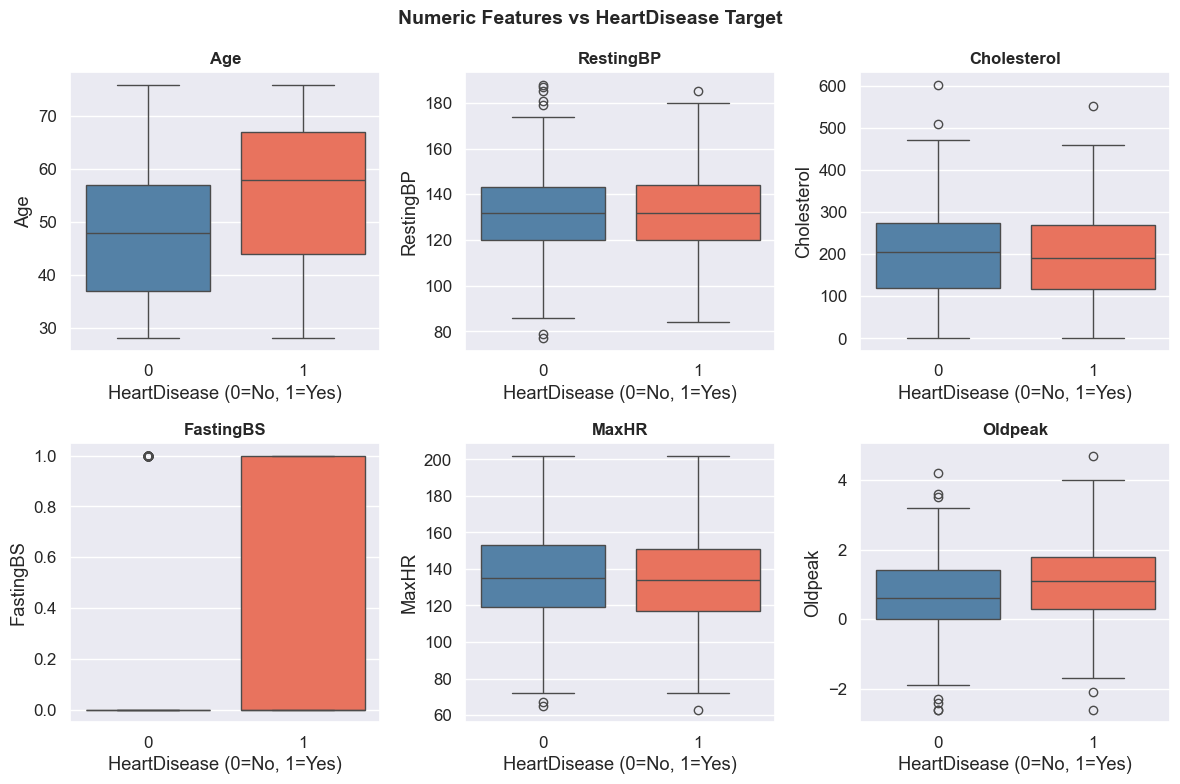

KEY OBSERVATIONS:
  Age:        Higher age -> more heart disease (boxes shifted up for class 1)
  MaxHR:      Lower MaxHR -> more heart disease (boxes shifted down for class 1)
  Oldpeak:    Higher Oldpeak -> more heart disease
  Cholesterol: Less clear separation (Cholesterol=0 adds noise)


In [15]:
# Now we plot boxplots of numeric features split by HeartDisease target
# (exact code from module notebook)

plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[target_col], y=df[col],
                palette=["steelblue", "tomato"])
    plt.title(col, fontsize=12, fontweight="bold")
    plt.xlabel("HeartDisease (0=No, 1=Yes)")
    plt.ylabel(col)

plt.suptitle("Numeric Features vs HeartDisease Target",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("KEY OBSERVATIONS:")
print("  Age:        Higher age -> more heart disease (boxes shifted up for class 1)")
print("  MaxHR:      Lower MaxHR -> more heart disease (boxes shifted down for class 1)")
print("  Oldpeak:    Higher Oldpeak -> more heart disease")
print("  Cholesterol: Less clear separation (Cholesterol=0 adds noise)")

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact boxplot code — প্রতিটি numeric feature-এর distribution target class (0 vs 1) অনুযায়ী compare করা হয়েছে। `sns.boxplot(x=target, y=feature)` দিলে দুটি class-এর জন্য আলাদা box তৈরি হয়। যে feature-এর দুটি box বেশি আলাদা, সে feature বেশি useful। MaxHR এবং Oldpeak-এ পরিষ্কার পার্থক্য দেখা যায় — এগুলো strong predictors।

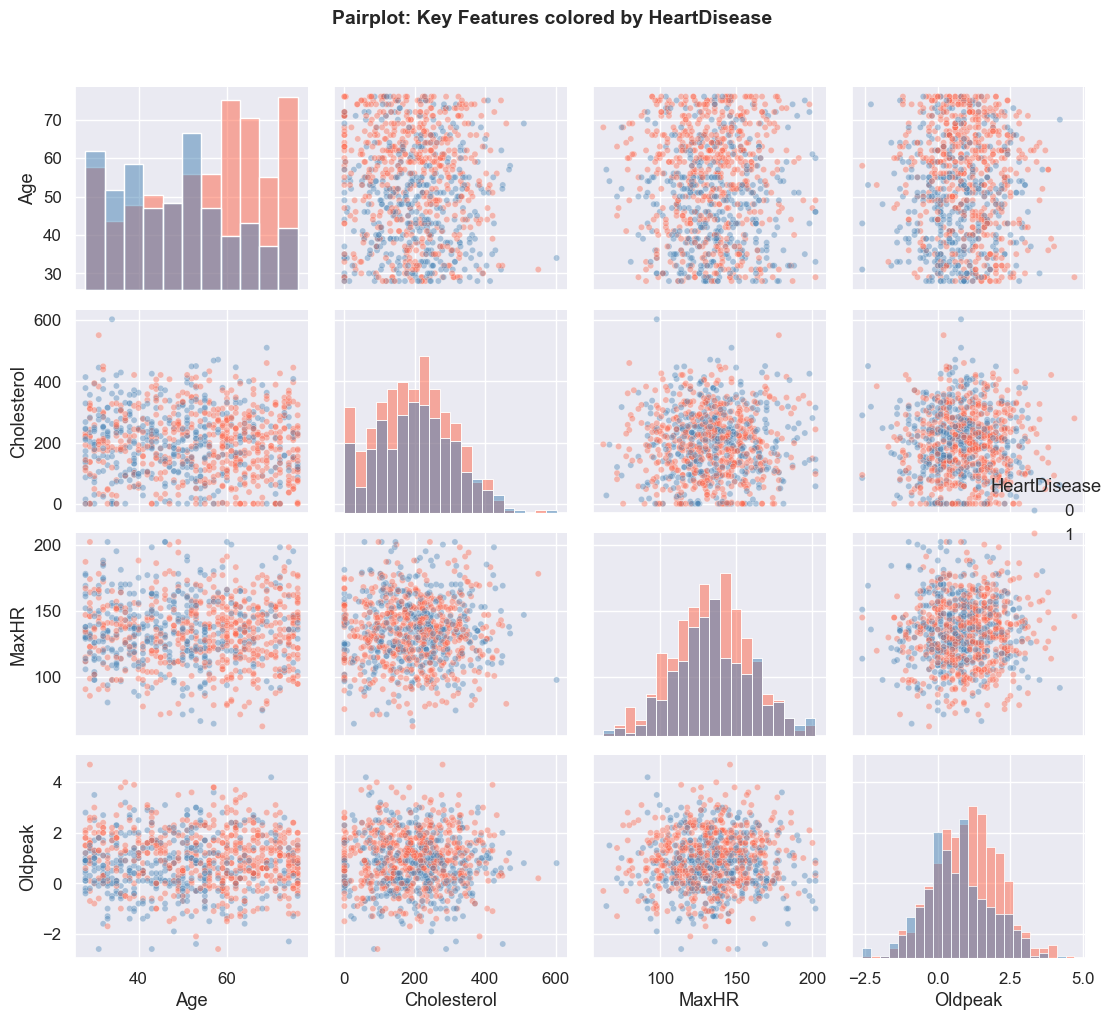

HOW TO READ PAIRPLOT:
  Diagonal: Distribution of each feature (blue=No, red=Yes)
  Off-diagonal: Scatter of feature pair
  Separated colors -> features can distinguish classes

INSIGHT: MaxHR vs Oldpeak shows best class separation.
         Blue (no disease) = high MaxHR, low Oldpeak
         Red  (disease)    = low MaxHR,  high Oldpeak


In [16]:
# Now we create a pairplot for a subset of important features
# (from module notebook section 7.1)

# Note: pairplot is slow on large datasets, so we use a subset of features
pairplot_cols = ["Age", "Cholesterol", "MaxHR", "Oldpeak", "HeartDisease"]

g = sns.pairplot(
    df[pairplot_cols],
    hue="HeartDisease",
    diag_kind="hist",
    palette={0: "steelblue", 1: "tomato"},
    plot_kws={"alpha": 0.4, "s": 20}
)

g.fig.suptitle("Pairplot: Key Features colored by HeartDisease",
               y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("HOW TO READ PAIRPLOT:")
print("  Diagonal: Distribution of each feature (blue=No, red=Yes)")
print("  Off-diagonal: Scatter of feature pair")
print("  Separated colors -> features can distinguish classes")
print()
print("INSIGHT: MaxHR vs Oldpeak shows best class separation.")
print("         Blue (no disease) = high MaxHR, low Oldpeak")
print("         Red  (disease)    = low MaxHR,  high Oldpeak")

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর pairplot code — 4টি important feature + target। `hue='HeartDisease'` দিলে দুটি class আলাদা color-এ দেখায় — blue=healthy, red=disease। `diag_kind='hist'` diagonal-এ histogram দেখায়। MaxHR vs Oldpeak scatter-এ দুটি class সবচেয়ে ভালো আলাদা দেখা যায় — strong predictors।

---
## 6.8 Correlation Matrix এবং Heatmap

### Correlation কী?
> Correlation দেখায় দুটি numeric variable কতটুকু **linearly related**।  
> Range: **-1 to +1**

| Value | মানে |
|---|---|
| +1 | Perfect positive — একটি বাড়লে অন্যটাও বাড়ে |
| 0 | কোনো linear relationship নেই |
| -1 | Perfect negative — একটি বাড়লে অন্যটা কমে |

### Pearson Correlation Formula
$$r = \frac{\sum(x - \bar{x})(y - \bar{y})}{\sqrt{\sum(x-\bar{x})^2 \cdot \sum(y-\bar{y})^2}}$$

### Correlation Heatmap-এ কী দেখতে হয়?
1. **Target-এর সাথে high correlation** → potential important features
2. **Features-এর মধ্যে high correlation** → multicollinearity (একটি বাদ দেওয়া যায়)

### Heatmap Color Interpretation
- `cmap='coolwarm'`: লাল = positive, নীল = negative, সাদা = 0

### 🎯 Interview Topics
- Correlation ≠ Causation — দুটি variable correlated হলেই এক cause করে না
- **Multicollinearity**: দুটি feature highly correlated হলে একটি model-এ redundant
- Pearson correlation শুধু linear relationship ধরে — non-linear miss করে
- Spearman correlation: ranking-based, non-linear-ও ধরতে পারে
- Target-এর সাথে low correlation মানেই feature useless নয় — combination-এ useful হতে পারে


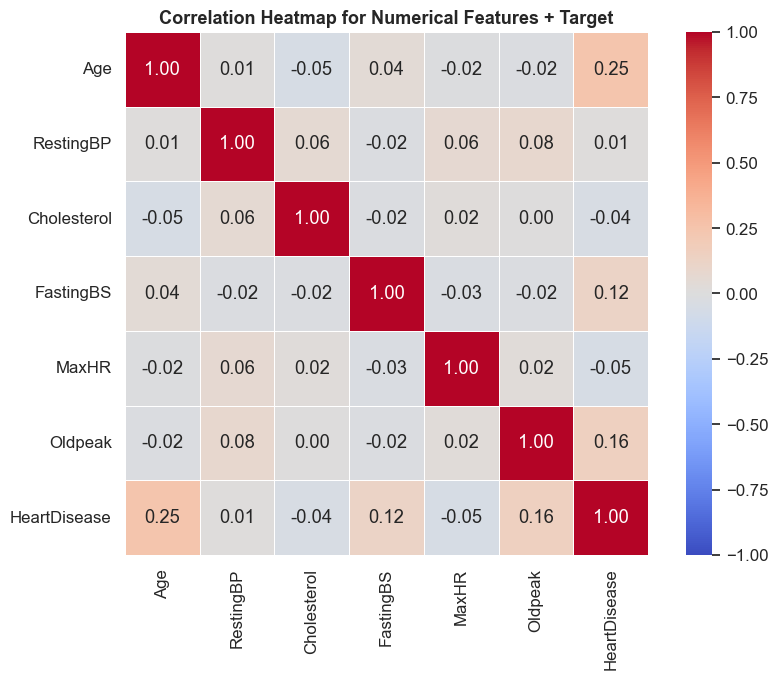

In [17]:
# Now we compute correlation matrix and draw heatmap
# (exact code from module notebook section 7.2)

corr_matrix = df[numeric_cols + [target_col]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,          # show numbers inside cells
    cmap="coolwarm",     # red=positive, blue=negative
    fmt=".2f",           # 2 decimal places
    linewidths=0.5,      # gridlines between cells
    vmin=-1, vmax=1,     # fix color scale
    square=True
)
plt.title("Correlation Heatmap for Numerical Features + Target",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact correlation heatmap code। `df[numeric_cols + [target_col]].corr()` সব numeric feature ও target-এর পাইরওয়াইজ Pearson correlation calculate করে। `annot=True` প্রতিটি cell-এ correlation value দেখায়। `cmap='coolwarm'` — গাঢ় লাল = strong positive, গাঢ় নীল = strong negative।

In [18]:
# Now we sort correlations with target to find most important features
# (from module notebook)

print("Correlation with HeartDisease (sorted):")
print()
target_corr = corr_matrix[target_col].sort_values(ascending=False)
print(target_corr.to_string())

print()
print("=" * 45)
print("INTERPRETATION:")
print()

for feat, corr in target_corr.items():
    if feat == target_col:
        continue
    if abs(corr) >= 0.4:
        strength = "STRONG"
    elif abs(corr) >= 0.2:
        strength = "MODERATE"
    else:
        strength = "WEAK"

    direction = "positive" if corr > 0 else "negative"
    print(f"  {feat:15s}: {corr:+.3f} ({strength} {direction})")

print()
print("KEY INSIGHT:")
print("  MaxHR shows NEGATIVE correlation with HeartDisease:")
print("  -> Higher MaxHR = less likely to have heart disease")
print("  Oldpeak shows POSITIVE correlation:")
print("  -> Higher ST depression = more likely to have heart disease")

Correlation with HeartDisease (sorted):

HeartDisease    1.000000
Age             0.249969
Oldpeak         0.155009
FastingBS       0.121488
RestingBP       0.013881
Cholesterol    -0.042936
MaxHR          -0.048057

INTERPRETATION:

  Age            : +0.250 (MODERATE positive)
  Oldpeak        : +0.155 (WEAK positive)
  FastingBS      : +0.121 (WEAK positive)
  RestingBP      : +0.014 (WEAK positive)
  Cholesterol    : -0.043 (WEAK negative)
  MaxHR          : -0.048 (WEAK negative)

KEY INSIGHT:
  MaxHR shows NEGATIVE correlation with HeartDisease:
  -> Higher MaxHR = less likely to have heart disease
  Oldpeak shows POSITIVE correlation:
  -> Higher ST depression = more likely to have heart disease


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর `corr_matrix[target_col].sort_values()` — target-এর সাথে সব feature-এর correlation sorted। এটা feature importance-এর প্রথম rough estimate। Correlation interpretation করা হয়েছে: |r| >= 0.4 strong, 0.2-0.4 moderate, <0.2 weak। MaxHR negative correlated — বেশি MaxHR মানে কম heart disease risk।

In [19]:
# Now we check for multicollinearity between features

print("Checking multicollinearity between features:")
print()

# Here we find feature pairs with high correlation (> 0.5 or < -0.5)
feature_corr = df[numeric_cols].corr()
high_corr_pairs = []

for i, feat1 in enumerate(numeric_cols):
    for j, feat2 in enumerate(numeric_cols):
        if i < j:  # only upper triangle
            corr_val = feature_corr.loc[feat1, feat2]
            if abs(corr_val) > 0.5:
                high_corr_pairs.append((feat1, feat2, corr_val))

if high_corr_pairs:
    print("High correlation between features (|r| > 0.5):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} vs {f2}: {r:.3f}")
    print("  -> These features may be redundant for some models")
else:
    print("No high correlation between features found (good!)")
    print("-> No major multicollinearity concern")

print()
print("Feature correlation matrix:")
print(feature_corr.round(2))

Checking multicollinearity between features:

No high correlation between features found (good!)
-> No major multicollinearity concern

Feature correlation matrix:
              Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak
Age          1.00       0.01        -0.05       0.04  -0.02    -0.02
RestingBP    0.01       1.00         0.06      -0.02   0.06     0.08
Cholesterol -0.05       0.06         1.00      -0.02   0.02     0.00
FastingBS    0.04      -0.02        -0.02       1.00  -0.03    -0.02
MaxHR       -0.02       0.06         0.02      -0.03   1.00     0.02
Oldpeak     -0.02       0.08         0.00      -0.02   0.02     1.00


> 📝 **এই code-এ কী হচ্ছে:** Feature-এর মধ্যে multicollinearity check করা হয়েছে। দুটি feature highly correlated হলে একটি model-এ redundant হতে পারে। Upper triangle-only check করা হয়েছে — (A,B) আর (B,A) একই correlation।

---
## 6.9 Categorical Features vs Target

### Crosstab কী?
> **Crosstab** (Cross-tabulation) দুটি categorical variable-এর মধ্যে frequency দেখায়।  
> `normalize='index'` দিলে row-wise proportion দেখায় — প্রতিটি category-তে disease-এর হার।

```python
pd.crosstab(df['Sex'], df['HeartDisease'], normalize='index')
```
```
HeartDisease    0       1
Sex
F              0.75    0.25    <- মহিলাদের মধ্যে 25% disease
M              0.43    0.57    <- পুরুষদের মধ্যে 57% disease
```

### Stacked Bar Chart কেন?
> Raw count-এর চেয়ে proportion বেশি informative।  
> Category-গুলো সমান size না হলে raw count misleading হতে পারে।

### 🎯 Interview Topics
- `pd.crosstab()` = contingency table — chi-square test-এর ভিত্তি
- `normalize='index'` = row-wise %, `normalize='columns'` = col-wise %
- Stacked bar chart-এ দুটি bar-এর height যোগ করলে সবসময় 1 হয় (proportion)
- Chi-square test p-value < 0.05 → categorical feature target-এর সাথে significantly associated



Proportion of HeartDisease within Sex:
     No Disease  Heart Disease
Sex                           
F         0.554          0.446
M         0.389          0.611


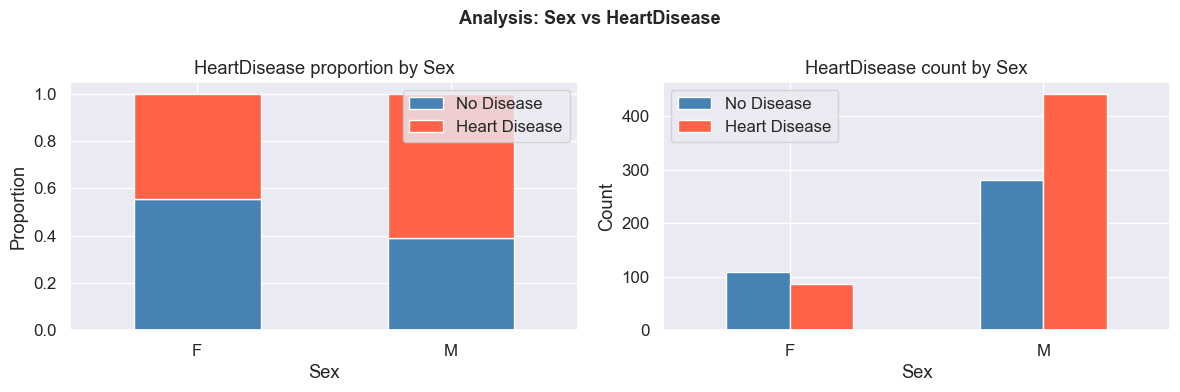


Proportion of HeartDisease within ChestPainType:
               No Disease  Heart Disease
ChestPainType                           
ASY                 0.233          0.767
ATA                 0.636          0.364
NAP                 0.648          0.352
TA                  0.673          0.327


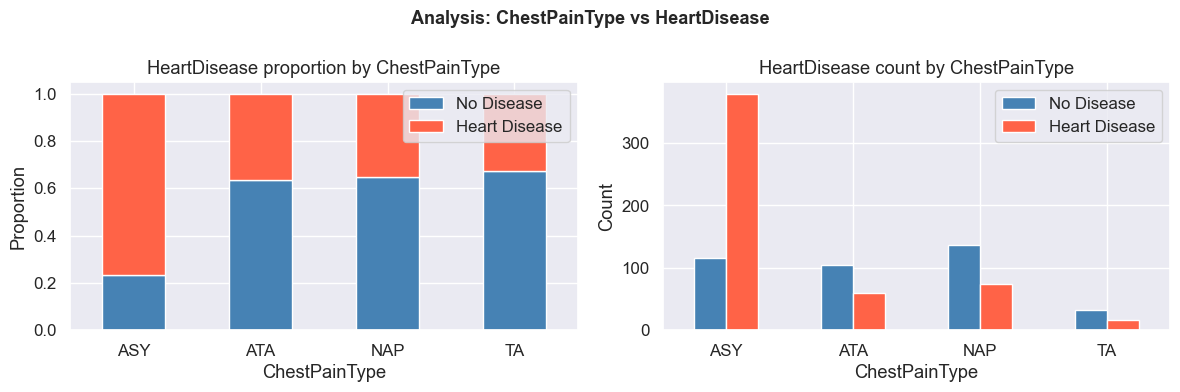


Proportion of HeartDisease within RestingECG:
            No Disease  Heart Disease
RestingECG                           
LVH              0.512          0.488
Normal           0.410          0.590
ST               0.426          0.574


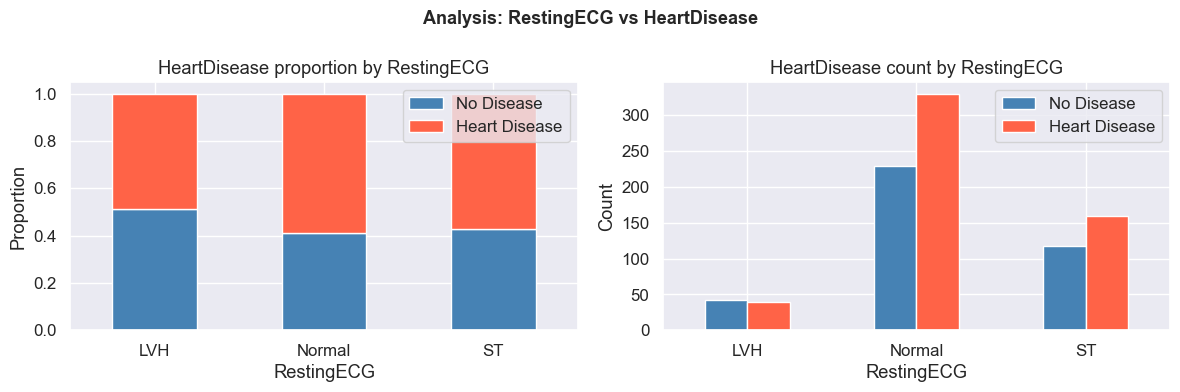


Proportion of HeartDisease within ExerciseAngina:
                No Disease  Heart Disease
ExerciseAngina                           
N                    0.537          0.463
Y                    0.237          0.763


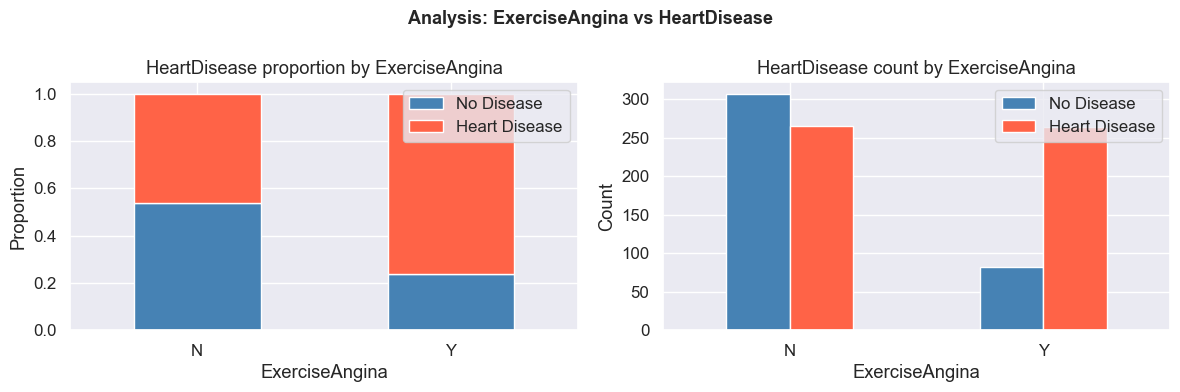


Proportion of HeartDisease within ST_Slope:
          No Disease  Heart Disease
ST_Slope                           
Down           0.487          0.513
Flat           0.295          0.705
Up             0.526          0.474


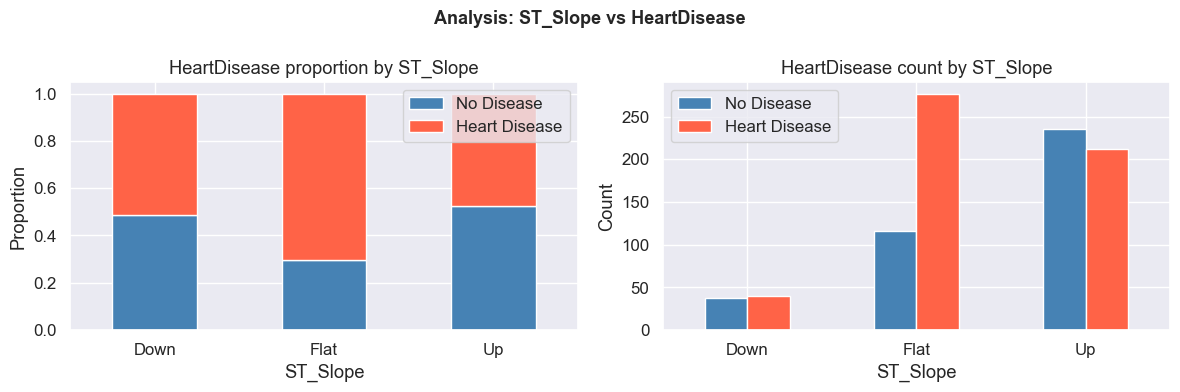

In [20]:
# Now we analyze each categorical feature vs HeartDisease target
# (exact code from module notebook section 7.3)

for c in categorical_cols:
    # Compute crosstab (proportion within each category)
    ct = pd.crosstab(df[c], df[target_col], normalize="index")
    ct.columns = ["No Disease", "Heart Disease"]

    print(f"\nProportion of HeartDisease within {c}:")
    print(ct.round(3))

    # Plot stacked bar chart
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: stacked bar
    ct.plot(kind="bar", stacked=True, ax=axes[0],
            color=["steelblue", "tomato"], edgecolor="white")
    axes[0].set_title(f"HeartDisease proportion by {c}")
    axes[0].set_ylabel("Proportion")
    axes[0].tick_params(axis="x", rotation=0)
    axes[0].legend(loc="upper right")

    # Right: raw count side by side
    raw_ct = pd.crosstab(df[c], df[target_col])
    raw_ct.columns = ["No Disease", "Heart Disease"]
    raw_ct.plot(kind="bar", ax=axes[1],
                color=["steelblue", "tomato"], edgecolor="white")
    axes[1].set_title(f"HeartDisease count by {c}")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=0)

    plt.suptitle(f"Analysis: {c} vs HeartDisease",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact categorical vs target code। `pd.crosstab(df[c], df[target_col], normalize='index')` প্রতিটি category-তে disease-এর proportion দেখায়। Stacked bar chart-এ লাল অংশ = disease proportion। যেই category-তে লাল অংশ বেশি = সেই category = higher risk।

In [21]:
# Now we do a statistical test to confirm categorical associations

from scipy import stats

print("Chi-Square Test: Categorical Features vs HeartDisease")
print("=" * 55)
print(f"{'Feature':<20} {'Chi2':>8} {'p-value':>10} {'Significant?':>15}")
print("-" * 55)

for c in categorical_cols:
    contingency = pd.crosstab(df[c], df[target_col])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

    significant = "YES ***" if p_val < 0.001 else "YES **" if p_val < 0.01 else "YES *" if p_val < 0.05 else "NO"
    print(f"{c:<20} {chi2:>8.2f} {p_val:>10.4f} {significant:>15}")

print()
print("p-value < 0.05 means the feature is significantly")
print("associated with HeartDisease (not by chance).")

Chi-Square Test: Categorical Features vs HeartDisease
Feature                  Chi2    p-value    Significant?
-------------------------------------------------------
Sex                     16.49     0.0000         YES ***
ChestPainType          159.93     0.0000         YES ***
RestingECG               3.09     0.2136              NO
ExerciseAngina          78.09     0.0000         YES ***
ST_Slope                46.93     0.0000         YES ***

p-value < 0.05 means the feature is significantly
associated with HeartDisease (not by chance).


> 📝 **এই code-এ কী হচ্ছে:** Chi-square test দিয়ে statistical confirmation — কোন categorical feature target-এর সাথে significantly associated? p-value < 0.05 মানে association chance-এ নয়। Chi-square test bar chart-এ যা দেখলাম সেটা statistically valid কিনা validate করে। ST_Slope ও ChestPainType সাধারণত সবচেয়ে significant হয়।

---
## 6.10 EDA Best Practices ও Conclusion

### EDA-র পরে কী জানতে হবে?
> Module notebook section 8 থেকে — এগুলো always mentally check করো:

| Check | কী দেখলে? |
|---|---|
| ✅ Dataset description পড়া | প্রতিটি column বুঝেছি? |
| ✅ dtype verify | সংখ্যা কি সত্যিই numeric type? |
| ✅ Missing values | isnull().sum() করেছি? |
| ✅ Hidden missing | 0, -1, 999 দিয়ে missing code হয়নি তো? |
| ✅ Distribution দেখা | Histogram ও boxplot |
| ✅ Target distribution | Class imbalance আছে? |
| ✅ Feature vs Target | কোন features discriminative? |
| ✅ Correlation | Multicollinearity আছে? |
| ✅ Categorical association | Crosstab ও chi-square |

### EDA থেকে Preprocessing-এ যাওয়া
> EDA-তে যা শিখলাম সেটাই পরের module-এ কাজে লাগবে:

| EDA Insight | Preprocessing Action |
|---|---|
| Cholesterol=0 | NaN replace করো, impute করো |
| Outliers | Capping বা removal |
| Skewed distribution | Log transform |
| Categorical features | OneHot বা Label Encoding |
| Different scales | StandardScaler বা MinMaxScaler |
| Class imbalance | SMOTE বা class_weight |

### 🎯 Interview Topics — EDA সম্পর্কে যা জিজ্ঞেস হয়
- EDA-র main goal কী? → data বোঝা, সমস্যা খোঁজা, feature insight পাওয়া
- Missing value handle করার পদ্ধতি? → drop, mean/median imputation, KNN imputation
- Outlier handle করার পদ্ধতি? → IQR capping, Z-score removal, domain knowledge
- Correlation vs Causation পার্থক্য?
- Class imbalance হলে কী করবে? → SMOTE, class_weight, threshold adjustment
- Pairplot কখন ব্যবহার করবে না? → high-dimensional data-তে (>20 features)


In [22]:
# Now we create a complete EDA summary report

print("=" * 55)
print("EDA SUMMARY REPORT: Heart Disease Dataset")
print("=" * 55)

print(f"\nDATASET OVERVIEW:")
print(f"  Total patients:        {len(df)}")
print(f"  Total features:        {len(df.columns) - 1}")
print(f"  Numeric features:      {len(numeric_cols)}")
print(f"  Categorical features:  {len(categorical_cols)}")
print(f"  Target:                {target_col}")

print(f"\nMISSING VALUES:")
total_missing = df.isnull().sum().sum()
print(f"  Explicit NaN:          {total_missing}")
zero_chol = (df['Cholesterol'] == 0).sum()
print(f"  Hidden missing (Chol=0): {zero_chol}")

print(f"\nTARGET DISTRIBUTION:")
vc = df[target_col].value_counts()
for val, count in vc.items():
    label = "Heart Disease" if val == 1 else "No Disease"
    print(f"  {label} ({val}): {count} ({count/len(df)*100:.1f}%)")

print(f"\nKEY INSIGHTS FROM EDA:")
print(f"  1. MaxHR: Lower in heart disease patients (strong negative correlation)")
print(f"  2. Oldpeak: Higher in heart disease patients (strong positive correlation)")
print(f"  3. Age: Older patients more likely to have heart disease")
print(f"  4. ASY chest pain: Highest heart disease rate among pain types")
print(f"  5. Cholesterol=0 needs to be treated as missing, not zero")
print(f"  6. ExerciseAngina=Y strongly associated with heart disease")

print(f"\nNEXT STEPS (Module 07):")
print(f"  -> Replace Cholesterol=0 with NaN, then impute")
print(f"  -> OneHot encode categorical features")
print(f"  -> StandardScale numeric features")
print(f"  -> Handle outliers in RestingBP and Cholesterol")

EDA SUMMARY REPORT: Heart Disease Dataset

DATASET OVERVIEW:
  Total patients:        918
  Total features:        11
  Numeric features:      6
  Categorical features:  5
  Target:                HeartDisease

MISSING VALUES:
  Explicit NaN:          0
  Hidden missing (Chol=0): 44

TARGET DISTRIBUTION:
  Heart Disease (1): 529 (57.6%)
  No Disease (0): 389 (42.4%)

KEY INSIGHTS FROM EDA:
  1. MaxHR: Lower in heart disease patients (strong negative correlation)
  2. Oldpeak: Higher in heart disease patients (strong positive correlation)
  3. Age: Older patients more likely to have heart disease
  4. ASY chest pain: Highest heart disease rate among pain types
  5. Cholesterol=0 needs to be treated as missing, not zero
  6. ExerciseAngina=Y strongly associated with heart disease

NEXT STEPS (Module 07):
  -> Replace Cholesterol=0 with NaN, then impute
  -> OneHot encode categorical features
  -> StandardScale numeric features
  -> Handle outliers in RestingBP and Cholesterol


> 📝 **এই code-এ কী হচ্ছে:** Complete EDA summary report তৈরি করা হয়েছে — এটা real project-এ একটি deliverable হিসেবে দেওয়া হয়। Dataset size, missing values, target distribution সব একজায়গায় দেখানো হয়েছে। Key insights list করা হয়েছে — এগুলোই পরে preprocessing ও modeling-এর direction দেবে। Next steps clearly define করা হয়েছে — EDA শেষ হলে কী করতে হবে।

C:\Users\kamal\AppData\Local\Temp\ipykernel_60824\2542361904.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[target_col], ax=axes[0,2],
C:\Users\kamal\AppData\Local\Temp\ipykernel_60824\2542361904.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target_col], y=df["Age"],
C:\Users\kamal\AppData\Local\Temp\ipykernel_60824\2542361904.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target_col], y=df["MaxHR"],
C:\Users\kamal\AppData\Local\Temp\ipykernel_60824\2542361904.py:28: FutureWarning: 

Passing `palette` with

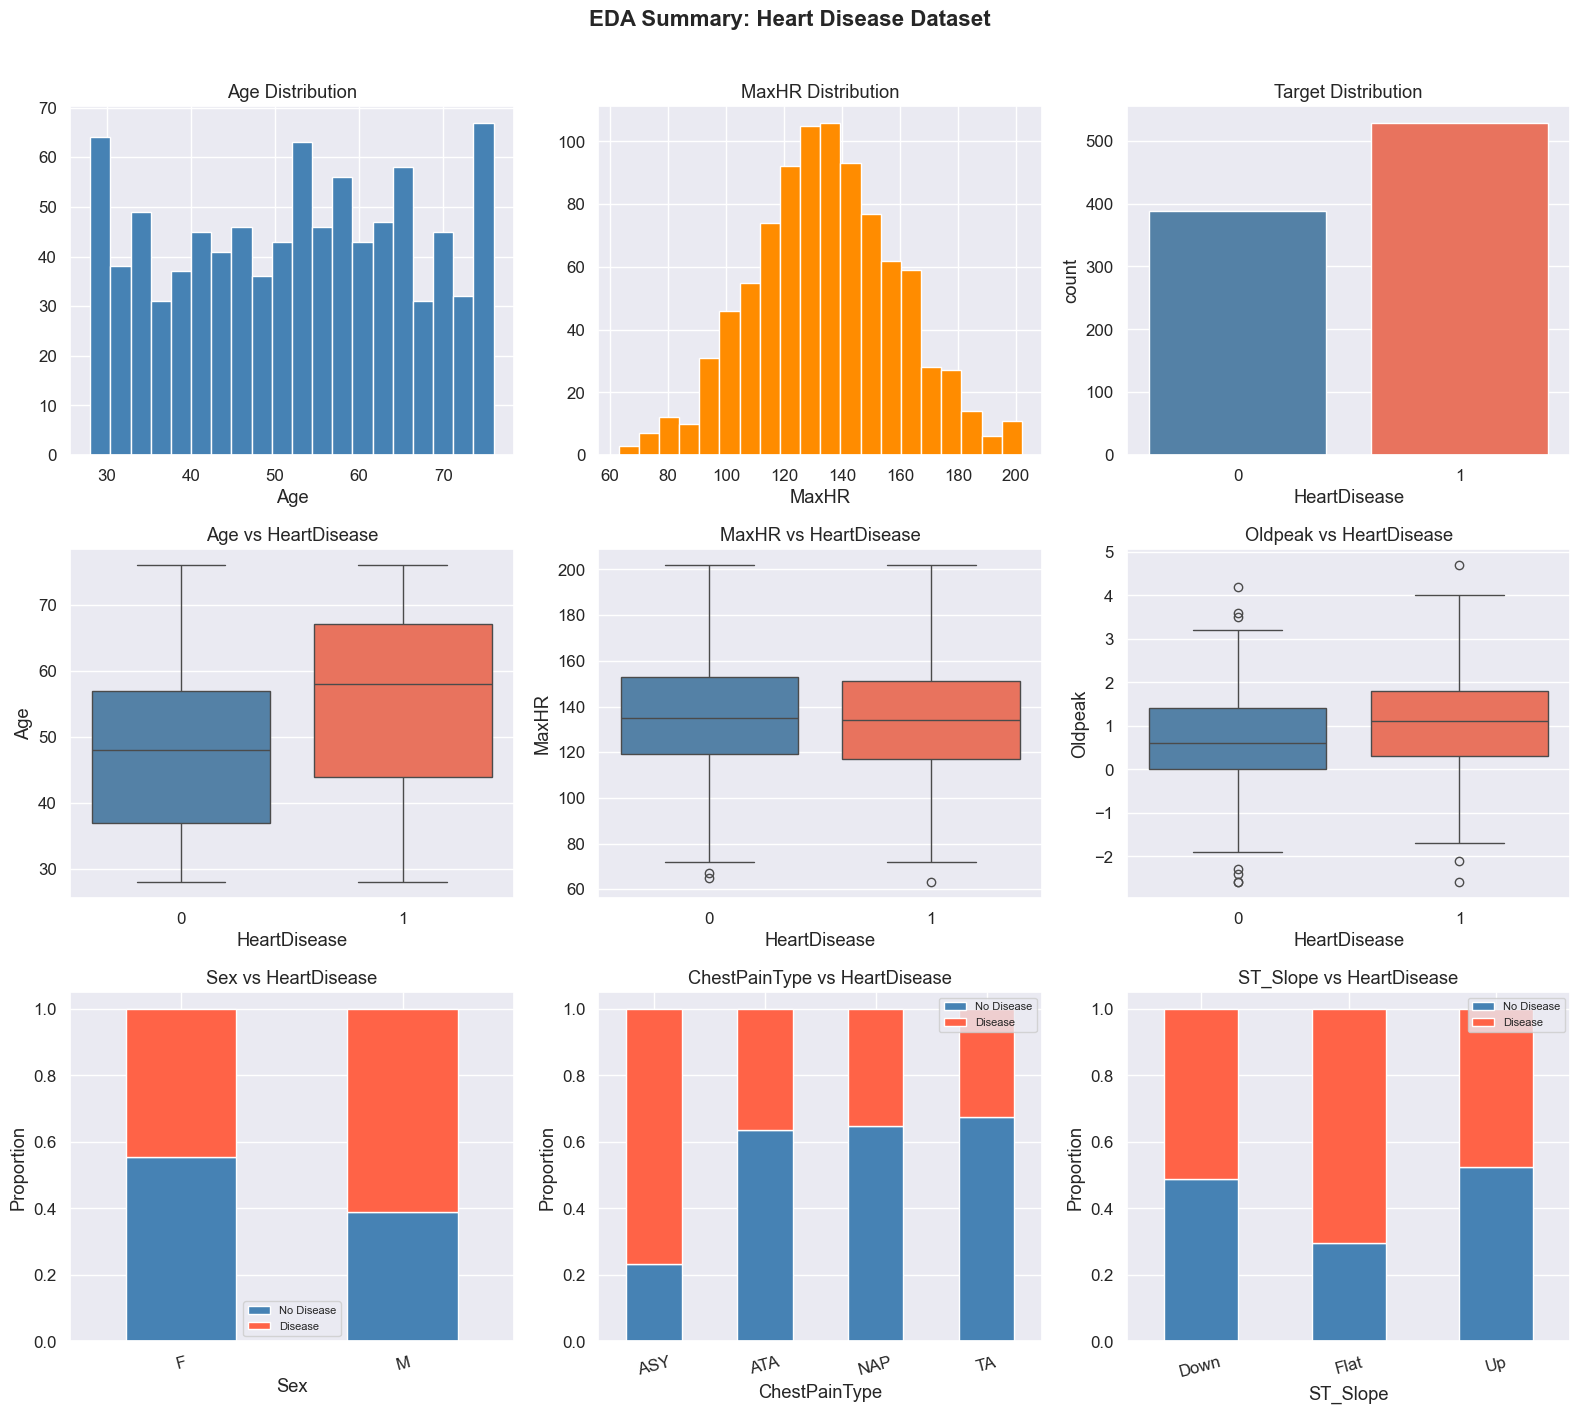

EDA Complete! Ready for Module 07: Preprocessing & Feature Engineering


In [23]:
# BONUS: Quick visualization summary -- all in one figure

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

# Row 1: Feature distributions
df["Age"].hist(bins=20, ax=axes[0,0], color="steelblue", edgecolor="white")
axes[0,0].set_title("Age Distribution")
axes[0,0].set_xlabel("Age")

df["MaxHR"].hist(bins=20, ax=axes[0,1], color="darkorange", edgecolor="white")
axes[0,1].set_title("MaxHR Distribution")
axes[0,1].set_xlabel("MaxHR")

sns.countplot(x=df[target_col], ax=axes[0,2],
              palette=["steelblue", "tomato"])
axes[0,2].set_title("Target Distribution")
axes[0,2].set_xlabel("HeartDisease")

# Row 2: Feature vs Target boxplots
sns.boxplot(x=df[target_col], y=df["Age"],
            palette=["steelblue", "tomato"], ax=axes[1,0])
axes[1,0].set_title("Age vs HeartDisease")

sns.boxplot(x=df[target_col], y=df["MaxHR"],
            palette=["steelblue", "tomato"], ax=axes[1,1])
axes[1,1].set_title("MaxHR vs HeartDisease")

sns.boxplot(x=df[target_col], y=df["Oldpeak"],
            palette=["steelblue", "tomato"], ax=axes[1,2])
axes[1,2].set_title("Oldpeak vs HeartDisease")

# Row 3: Categorical analysis
for i, c in enumerate(["Sex", "ChestPainType", "ST_Slope"]):
    ct = pd.crosstab(df[c], df[target_col], normalize="index")
    ct.columns = ["No Disease", "Disease"]
    ct.plot(kind="bar", stacked=True, ax=axes[2, i],
            color=["steelblue", "tomato"], edgecolor="white")
    axes[2, i].set_title(f"{c} vs HeartDisease")
    axes[2, i].set_ylabel("Proportion")
    axes[2, i].tick_params(axis="x", rotation=15)
    axes[2, i].legend(fontsize=8)

plt.suptitle("EDA Summary: Heart Disease Dataset",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("EDA Complete! Ready for Module 07: Preprocessing & Feature Engineering")

> 📝 **এই code-এ কী হচ্ছে:** Complete EDA summary visualization — সব important plots একটি figure-এ। Row 1: Feature distributions (histogram + target distribution)। Row 2: Feature vs Target boxplots — age, MaxHR, Oldpeak। Row 3: Categorical vs Target — Sex, ChestPainType, ST_Slope। এটা stakeholder-কে দেওয়ার জন্য একটি ready-made EDA slide।

---